# 가우시안 혼합 모델(3개 분포)에서 t-노이즈로 샘플링

In [137]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 깨짐 방지 (Windows 기본 한글 폰트)
plt.rcParams["axes.unicode_minus"] = False

## 1. GMM 정의 (mode 3개)

In [138]:
means = np.array([
    [-1.5,  1.5],
    [ 1.5,  1.5],
    [-1.5, -1.5],
])
sigma = 0.6
weights = np.array([1 / 3, 1 / 3, 1 / 3])

def density(x1, x2, w=None):
    """배경 시각화용: 원래 GMM(정규분포 성분)의 밀도 p(x) = sum_k w_k * N(x; mu_k, sigma^2 I)."""
    if w is None:
        w = weights
    p = np.zeros_like(x1)
    for wk, mu in zip(w, means):
        d2 = (x1 - mu[0]) ** 2 + (x2 - mu[1]) ** 2
        p += wk * np.exp(-d2 / (2 * sigma ** 2)) / (2 * np.pi * sigma ** 2)
    return p

lim = 4
fine = np.linspace(-lim, lim, 300)
X1_fine, X2_fine = np.meshgrid(fine, fine)
P = density(X1_fine, X2_fine)

## 2. 다변량 t-노이즈로 샘플링하기

In [139]:
def sample_gmm_gaussian(n_samples, rng, w=None):
    """기준선: 원래 GMM대로 정규분포 노이즈로 샘플링."""
    if w is None:
        w = weights
    comp_idx = rng.choice(len(means), size=n_samples, p=w)
    return means[comp_idx] + rng.normal(scale=sigma, size=(n_samples, 2))

def sample_gmm_t(n_samples, df, rng, w=None):
    """카이제곱 스케일을 두 축이 공유하는 다변량 t-분포 노이즈로 샘플링."""
    if w is None:
        w = weights
    if df <= 2:
        raise ValueError("분산이 유한하려면 df > 2 이어야 한다")
    comp_idx = rng.choice(len(means), size=n_samples, p=w)
    z = rng.normal(size=(n_samples, 2))
    v = rng.chisquare(df, size=n_samples)
    noise = sigma * z / np.sqrt(v / df)[:, None]
    return means[comp_idx] + noise

## 3. 시각화: 정규분포 노이즈 vs t-노이즈

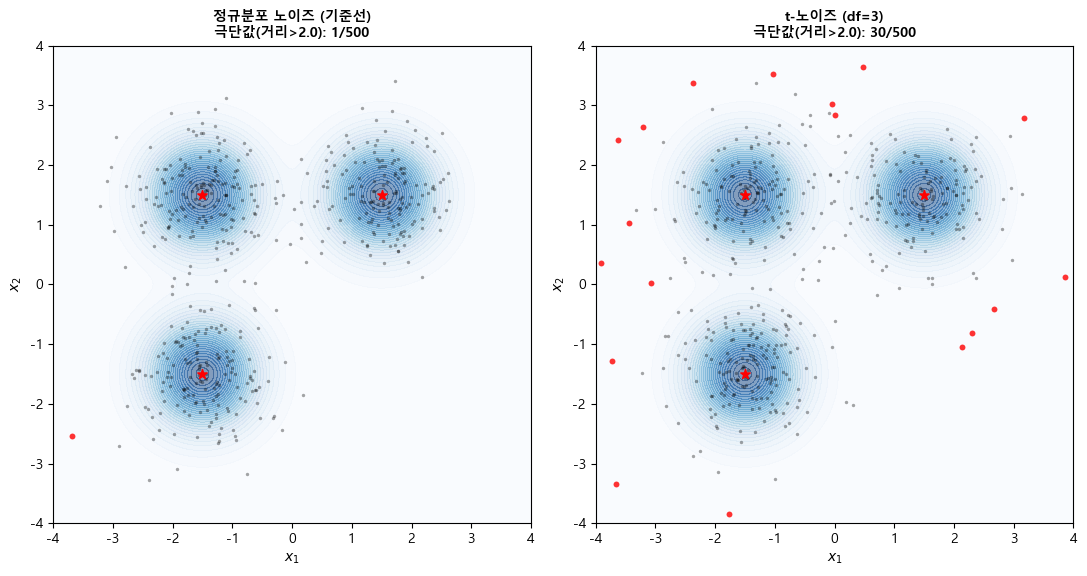

In [140]:
n_samples = 500
df = 3  # 자유도. 작을수록 꼬리가 두꺼워짐 (df>2 필요)
extreme_threshold = 2.0

rng = np.random.default_rng(42)
samples_gauss = sample_gmm_gaussian(n_samples, rng)
samples_t = sample_gmm_t(n_samples, df, rng)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, s, title in [
    (axes[0], samples_gauss, "정규분포 노이즈 (기준선)"),
    (axes[1], samples_t, f"t-노이즈 (df={df})"),
]:
    dist = np.min(np.linalg.norm(s[:, None, :] - means[None, :, :], axis=2), axis=1)
    is_extreme = dist > extreme_threshold
    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    ax.scatter(s[~is_extreme, 0], s[~is_extreme, 1], s=6, c="black", alpha=0.35, linewidths=0)
    ax.scatter(s[is_extreme, 0], s[is_extreme, 1], s=18, c="red", alpha=0.8, linewidths=0)
    ax.scatter(means[:, 0], means[:, 1], c="red", s=50, marker="*", zorder=5)
    ax.set_title(f"{title}\n극단값(거리>{extreme_threshold}): {int(is_extreme.sum())}/{n_samples}", fontweight="bold", fontsize=10)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 4. 자유도(df)에 따른 꼬리 두께 변화

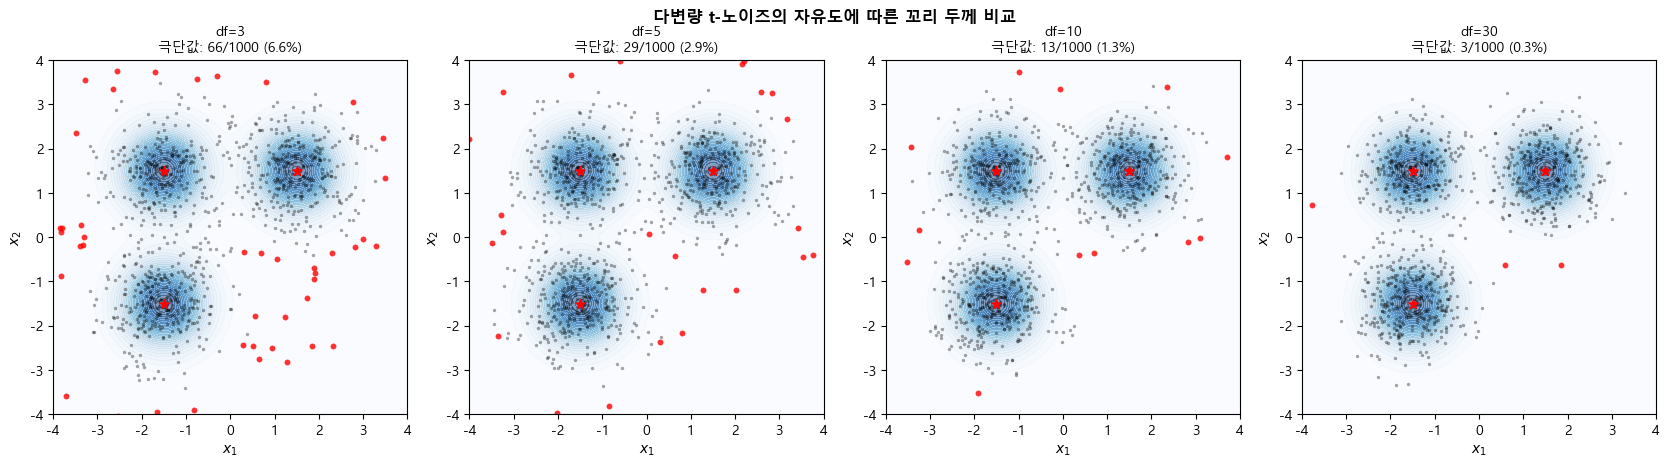

In [141]:
df_list = [3, 5, 10, 30]
n_samples_df = 1000
extreme_threshold_df = 2.0

fig2, axes2 = plt.subplots(1, len(df_list), figsize=(4.2 * len(df_list), 4.5))
for ax, df_i in zip(axes2, df_list):
    rng_df = np.random.default_rng(0)
    s = sample_gmm_t(n_samples_df, df_i, rng_df)
    dist = np.min(np.linalg.norm(s[:, None, :] - means[None, :, :], axis=2), axis=1)
    is_extreme = dist > extreme_threshold_df
    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    ax.scatter(s[~is_extreme, 0], s[~is_extreme, 1], s=6, c="black", alpha=0.35, linewidths=0)
    ax.scatter(s[is_extreme, 0], s[is_extreme, 1], s=18, c="red", alpha=0.8, linewidths=0)
    ax.scatter(means[:, 0], means[:, 1], c="red", s=50, marker="*", zorder=5)
    ax.set_title(f"df={df_i}\n극단값: {int(is_extreme.sum())}/{n_samples_df} ({100*is_extreme.sum()/n_samples_df:.1f}%)", fontsize=10)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

fig2.suptitle("다변량 t-노이즈의 자유도에 따른 꼬리 두께 비교", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. 스코어를 따라가며 샘플링하기 (Langevin dynamics + t-노이즈)

In [142]:
def score(x1, x2, w=None):
    """GMM(정규분포 성분) 스코어. plot_score_function.ipynb와 동일한 정의."""
    if w is None:
        w = weights
    p = density(x1, x2, w=w)
    grad_x1 = np.zeros_like(x1)
    grad_x2 = np.zeros_like(x2)
    for wk, mu in zip(w, means):
        d2 = (x1 - mu[0]) ** 2 + (x2 - mu[1]) ** 2
        n_k = np.exp(-d2 / (2 * sigma ** 2)) / (2 * np.pi * sigma ** 2)
        responsibility = wk * n_k / p
        grad_x1 += responsibility * (-(x1 - mu[0]) / sigma ** 2)
        grad_x2 += responsibility * (-(x2 - mu[1]) / sigma ** 2)
    return grad_x1, grad_x2

def _noise(shape, df, scale, rng, noise_mode):
    """Langevin 스텝에 더할 노이즈. noise_mode='gaussian'/'t', 분산은 scale**2으로 맞춘다."""
    if noise_mode == "gaussian":
        return rng.normal(scale=scale, size=shape)
    if noise_mode == "t":
        t_scale = scale / np.sqrt(df / (df - 2))
        n = shape[0]
        z = rng.normal(size=shape)
        v = rng.chisquare(df, size=n)
        return t_scale * z / np.sqrt(v / df)[:, None]
    raise ValueError(f"unknown noise_mode: {noise_mode}")

def follow_score_t(start_points, step_size, n_steps, df=3, noise_mode="t", score_fn=None, rng=None):
    """x_{t+1} = x_t + step_size * score_fn(x_t) + sqrt(2*step_size) * noise(mode)."""
    if score_fn is None:
        score_fn = score
    if rng is None:
        rng = np.random.default_rng(0)
    noise_scale = np.sqrt(2 * step_size)
    trajectories = np.zeros((n_steps + 1, *start_points.shape))
    trajectories[0] = start_points
    x = start_points.copy()
    for t in range(n_steps):
        gx, gy = score_fn(x[:, 0], x[:, 1])
        grad = np.stack([gx, gy], axis=1)
        noise = _noise(x.shape, df, noise_scale, rng, noise_mode)
        x = x + step_size * grad + noise
        trajectories[t + 1] = x
    return trajectories

### 5-1. 궤적: 몇 개 입자가 실제로 어떻게 움직이는가

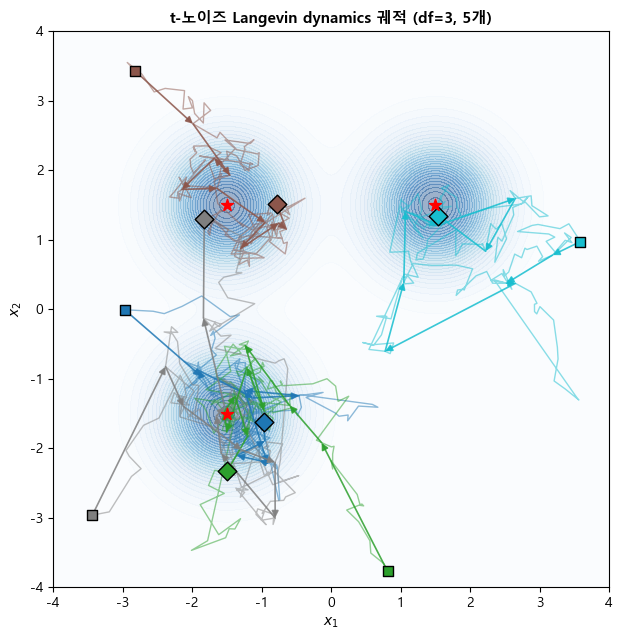

In [143]:
step_size = 0.02
n_steps_traj = 150
n_particles_traj = 5
df_traj = 3

rng_traj = np.random.default_rng(11)
start_traj = rng_traj.uniform(-lim, lim, size=(n_particles_traj, 2))
trajectories_traj = follow_score_t(
    start_traj, step_size=step_size, n_steps=n_steps_traj,
    df=df_traj, noise_mode="t", rng=rng_traj,
)
final_traj = trajectories_traj[-1]

colors_traj = plt.cm.tab10(np.linspace(0, 1, n_particles_traj))
arrow_step_traj = 15

fig3, ax3 = plt.subplots(figsize=(6.5, 6.5))
ax3.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.4)
for i in range(n_particles_traj):
    ax3.plot(trajectories_traj[:, i, 0], trajectories_traj[:, i, 1], color=colors_traj[i], alpha=0.5, linewidth=1, zorder=3)
    for t in range(0, n_steps_traj, arrow_step_traj):
        t_next = min(t + arrow_step_traj, n_steps_traj)
        x0, y0 = trajectories_traj[t, i]
        x1_, y1_ = trajectories_traj[t_next, i]
        ax3.annotate(
            "", xy=(x1_, y1_), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="-|>", color=colors_traj[i], alpha=0.85, lw=1.2, shrinkA=0, shrinkB=0),
            zorder=4,
        )
    ax3.scatter(*start_traj[i], color=colors_traj[i], s=60, marker="s", zorder=5, edgecolor="black")
    ax3.scatter(*final_traj[i], color=colors_traj[i], s=90, marker="D", zorder=6, edgecolor="black")
ax3.scatter(means[:, 0], means[:, 1], c="red", s=80, marker="*", zorder=7)
ax3.set_title(f"t-노이즈 Langevin dynamics 궤적 (df={df_traj}, {n_particles_traj}개)", fontweight="bold", fontsize=11)
ax3.set_xlabel(r"$x_1$")
ax3.set_ylabel(r"$x_2$")
ax3.set_xlim(-lim, lim)
ax3.set_ylim(-lim, lim)
ax3.set_aspect("equal")

plt.tight_layout()
plt.show()

### 5-2. 최종 분포 비교: 정규분포 노이즈 vs t-노이즈

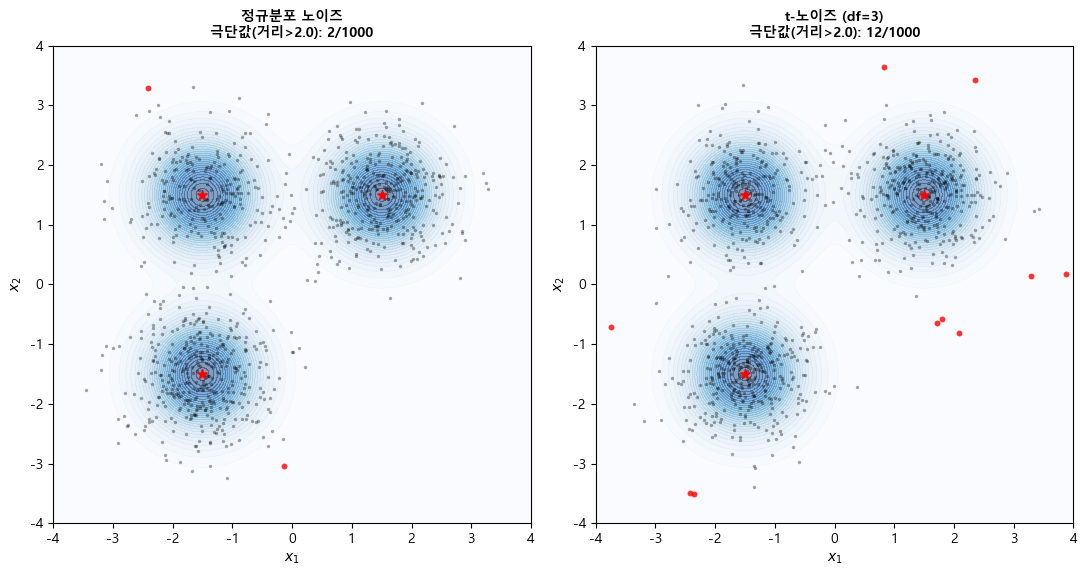

In [144]:
n_particles_final = 1000
n_steps_final = 150
df_final = 3
extreme_threshold_final = 2.0

fig4, axes4 = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, noise_mode, title in [
    (axes4[0], "gaussian", "정규분포 노이즈"),
    (axes4[1], "t", f"t-노이즈 (df={df_final})"),
]:
    rng_final = np.random.default_rng(5)
    start_final = rng_final.uniform(-lim, lim, size=(n_particles_final, 2))
    traj_final = follow_score_t(
        start_final, step_size=step_size, n_steps=n_steps_final,
        df=df_final, noise_mode=noise_mode, rng=rng_final,
    )
    end_points = traj_final[-1]
    dist = np.min(np.linalg.norm(end_points[:, None, :] - means[None, :, :], axis=2), axis=1)
    is_extreme = dist > extreme_threshold_final

    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    ax.scatter(end_points[~is_extreme, 0], end_points[~is_extreme, 1], s=6, c="black", alpha=0.35, linewidths=0)
    ax.scatter(end_points[is_extreme, 0], end_points[is_extreme, 1], s=18, c="red", alpha=0.8, linewidths=0)
    ax.scatter(means[:, 0], means[:, 1], c="red", s=50, marker="*", zorder=5)
    ax.set_title(f"{title}\n극단값(거리>{extreme_threshold_final}): {int(is_extreme.sum())}/{n_particles_final}", fontweight="bold", fontsize=10)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### 5-3. 여러 시드로 반복해서 통계로 확인하기

In [152]:
n_trials = 20
n_particles_stat = 500
n_steps_stat = 150
df_stat = 3
extreme_threshold_stat = 2.0

frac_gauss = np.zeros(n_trials)
frac_t = np.zeros(n_trials)

for trial in range(n_trials):
    seed = 1000 + trial

    rng_g = np.random.default_rng(seed)
    start_g = rng_g.uniform(-lim, lim, size=(n_particles_stat, 2))
    end_g = follow_score_t(start_g, step_size=step_size, n_steps=n_steps_stat, df=df_stat, noise_mode="gaussian", rng=rng_g)[-1]

    rng_t = np.random.default_rng(seed)  # 정규분포와 동일한 시작점을 쓰기 위해 같은 시드로 재시작
    start_t = rng_t.uniform(-lim, lim, size=(n_particles_stat, 2))
    end_t = follow_score_t(start_t, step_size=step_size, n_steps=n_steps_stat, df=df_stat, noise_mode="t", rng=rng_t)[-1]

    dist_g = np.min(np.linalg.norm(end_g[:, None, :] - means[None, :, :], axis=2), axis=1)
    dist_t = np.min(np.linalg.norm(end_t[:, None, :] - means[None, :, :], axis=2), axis=1)
    frac_gauss[trial] = np.mean(dist_g > extreme_threshold_stat)
    frac_t[trial] = np.mean(dist_t > extreme_threshold_stat)

n_t_wins = int(np.sum(frac_t > frac_gauss))
n_g_wins = int(np.sum(frac_gauss > frac_t))
n_ties = n_trials - n_t_wins - n_g_wins

print(f"시드 {n_trials}개, 시드당 입자 {n_particles_stat}개, threshold={extreme_threshold_stat}")
print()
print(f"정규분포 노이즈: 극단값 비율 평균={frac_gauss.mean():.4f}  표준편차={frac_gauss.std():.4f}")
print(f"t-노이즈       : 극단값 비율 평균={frac_t.mean():.4f}  표준편차={frac_t.std():.4f}")
print()
print(f"시드별 비교: t가 더 큼={n_t_wins}/{n_trials}  정규분포가 더 큼={n_g_wins}/{n_trials}  동률={n_ties}/{n_trials}")

diff = frac_t - frac_gauss
print()
print(f"차이(t - 정규분포) 평균={diff.mean():.4f}  표준편차={diff.std():.4f}")
print(f"평균의 표준오차(SEM)={diff.std(ddof=1)/np.sqrt(n_trials):.4f}")
t_stat = diff.mean() / (diff.std(ddof=1) / np.sqrt(n_trials))
print(f"대응표본(paired) t-통계량 ≈ {t_stat:.2f}  (자유도={n_trials - 1}, |t|>~2면 유의미한 차이로 볼 수 있음)")

시드 20개, 시드당 입자 500개, threshold=2.0

정규분포 노이즈: 극단값 비율 평균=0.0025  표준편차=0.0025
t-노이즈       : 극단값 비율 평균=0.0108  표준편차=0.0050

시드별 비교: t가 더 큼=17/20  정규분포가 더 큼=1/20  동률=2/20

차이(t - 정규분포) 평균=0.0083  표준편차=0.0063
평균의 표준오차(SEM)=0.0015
대응표본(paired) t-통계량 ≈ 5.71  (자유도=19, |t|>~2면 유의미한 차이로 볼 수 있음)


### 5-4. `scipy.stats.ttest_rel`로 정식 paired t-test

In [153]:
from scipy import stats

ttest_result = stats.ttest_rel(frac_t, frac_gauss)
ci = ttest_result.confidence_interval(confidence_level=0.95)

print("paired t-test: t-노이즈 vs 정규분포 (극단값 비율, 시드 40개)")
print(f"  평균 차이 (t - 정규분포) = {diff.mean():.4f}")
print(f"  t-통계량 = {ttest_result.statistic:.3f}")
print(f"  p-value  = {ttest_result.pvalue:.7f}")
print(f"  95% 신뢰구간 = [{ci.low:.4f}, {ci.high:.4f}]")
print()
if ttest_result.pvalue < 0.05:
    print("-> p < 0.05: 유의수준 5%에서 통계적으로 유의미한 차이")
else:
    print("-> p >= 0.05: 유의수준 5%에서 통계적으로 유의미하다고 보기 어려움 (신뢰구간이 0을 포함)")

paired t-test: t-노이즈 vs 정규분포 (극단값 비율, 시드 40개)
  평균 차이 (t - 정규분포) = 0.0083
  t-통계량 = 5.713
  p-value  = 0.0000166
  95% 신뢰구간 = [0.0053, 0.0113]

-> p < 0.05: 유의수준 5%에서 통계적으로 유의미한 차이


## 6. 디퓨전처럼: 시작점도 노이즈 분포에서 뽑기

In [147]:
def gmm_overall_stats(n_mc=200_000, rng=None):
    """GMM(real data) 전체의 평균과 등방성 근사 표준편차를 몬테카를로로 추정.
    diffusion model의 forward process가 도달하는 노이즈 분포의 중심/퍼짐을 이 값에 맞춘다."""
    if rng is None:
        rng = np.random.default_rng(0)
    samples = sample_gmm_gaussian(n_mc, rng)
    mu_bar = samples.mean(axis=0)
    var_total = samples.var(axis=0).mean()  # 두 축 분산의 평균으로 등방성 근사
    return mu_bar, np.sqrt(var_total)

mu_bar, sigma_prior = gmm_overall_stats()
print(f"데이터 전체 평균 mu_bar = ({mu_bar[0]:.3f}, {mu_bar[1]:.3f})")
print(f"데이터 전체 표준편차(등방성 근사) sigma_prior = {sigma_prior:.3f}  (참고: 성분 sigma={sigma}, mode 3개 사이 퍼짐까지 합친 값)")

def sample_prior_gaussian(n_samples, rng, mu=None, scale=None):
    """디퓨전의 forward process 끝점(prior)을 흉내: 등방성 정규분포 노이즈."""
    if mu is None:
        mu = mu_bar
    if scale is None:
        scale = sigma_prior
    return mu + rng.normal(scale=scale, size=(n_samples, 2))

def sample_prior_t(n_samples, df, rng, mu=None, scale=None):
    """같은 자리에 분산만 맞춘 다변량 t-분포 노이즈 버전의 prior."""
    if mu is None:
        mu = mu_bar
    if scale is None:
        scale = sigma_prior
    if df <= 2:
        raise ValueError("분산이 유한하려면 df > 2 이어야 한다")
    t_scale = scale / np.sqrt(df / (df - 2))
    z = rng.normal(size=(n_samples, 2))
    v = rng.chisquare(df, size=n_samples)
    return mu + t_scale * z / np.sqrt(v / df)[:, None]

def run_prior_langevin(noise_mode, n_samples, df, step_size, n_steps, rng):
    """noise_mode='gaussian'/'t'에 맞는 prior에서 시작점을 뽑고, 같은 종류의 노이즈로 Langevin dynamics를 돌린다.
    가우시안 디퓨전 = 가우시안 prior + 가우시안 스텝 노이즈, t-디퓨전 = t prior + t 스텝 노이즈로 짝을 맞춘다."""
    if noise_mode == "gaussian":
        start = sample_prior_gaussian(n_samples, rng)
    elif noise_mode == "t":
        start = sample_prior_t(n_samples, df, rng)
    else:
        raise ValueError(f"unknown noise_mode: {noise_mode}")
    trajectories = follow_score_t(start, step_size=step_size, n_steps=n_steps, df=df, noise_mode=noise_mode, rng=rng)
    return start, trajectories

데이터 전체 평균 mu_bar = (-0.497, 0.503)
데이터 전체 표준편차(등방성 근사) sigma_prior = 1.537  (참고: 성분 sigma=0.6, mode 3개 사이 퍼짐까지 합친 값)


### 6-1. 궤적: 노이즈 분포에서 출발해 mode로 걸어가기

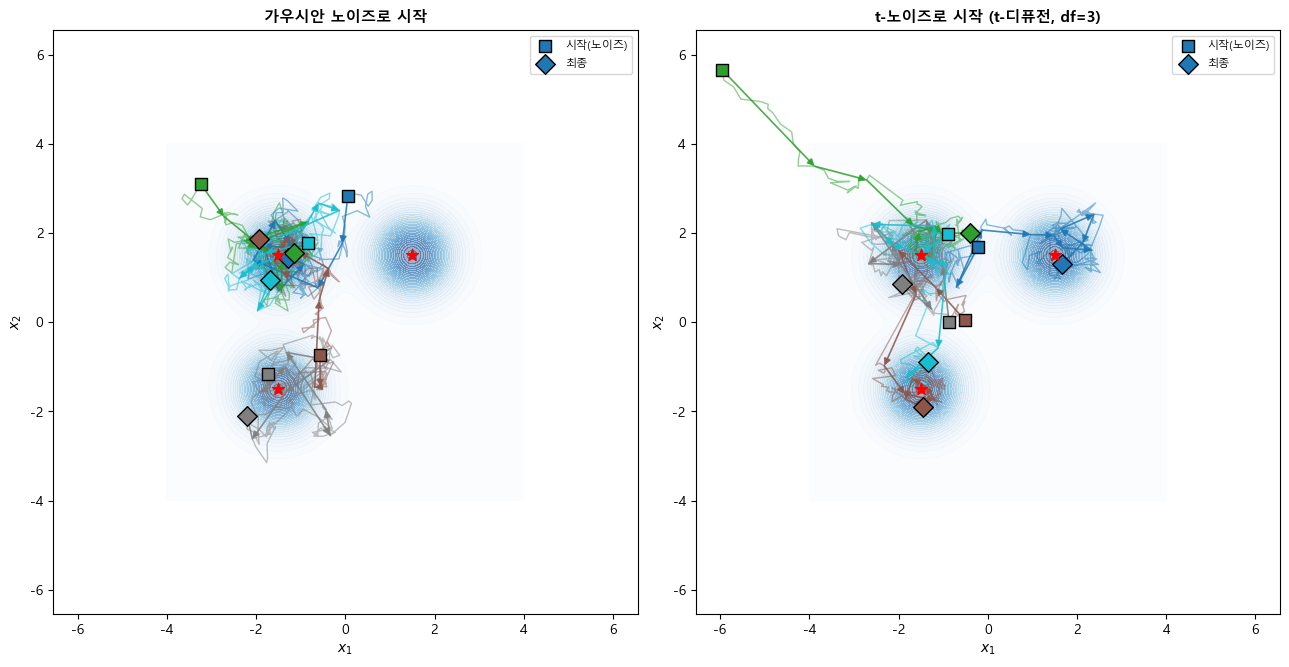

In [148]:
step_size = 0.02
n_steps_diff = 150
n_particles_diff = 5
df_diff = 3

rng_gd = np.random.default_rng(21)
start_gauss_diff, traj_gauss_diff = run_prior_langevin("gaussian", n_particles_diff, df_diff, step_size, n_steps_diff, rng_gd)

rng_td = np.random.default_rng(21)  # 같은 시드로 t prior에서도 뽑아서 공정하게 비교
start_t_diff, traj_t_diff = run_prior_langevin("t", n_particles_diff, df_diff, step_size, n_steps_diff, rng_td)

lim_diff = max(lim, float(np.abs(np.concatenate([start_gauss_diff, start_t_diff])).max()) * 1.1)
colors_diff = plt.cm.tab10(np.linspace(0, 1, n_particles_diff))
arrow_step_diff = 15

fig7, (axG7, axT7) = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, traj, start, title in [
    (axG7, traj_gauss_diff, start_gauss_diff, "가우시안 노이즈로 시작"),
    (axT7, traj_t_diff, start_t_diff, f"t-노이즈로 시작 (t-디퓨전, df={df_diff})"),
]:
    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.4)
    for i in range(n_particles_diff):
        ax.plot(traj[:, i, 0], traj[:, i, 1], color=colors_diff[i], alpha=0.5, linewidth=1, zorder=3)
        for t in range(0, n_steps_diff, arrow_step_diff):
            t_next = min(t + arrow_step_diff, n_steps_diff)
            x0, y0 = traj[t, i]
            x1_, y1_ = traj[t_next, i]
            ax.annotate(
                "", xy=(x1_, y1_), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=colors_diff[i], alpha=0.85, lw=1.2, shrinkA=0, shrinkB=0),
                zorder=4,
            )
        ax.scatter(*start[i], color=colors_diff[i], s=70, marker="s", zorder=5, edgecolor="black", label="시작(노이즈)" if i == 0 else None)
        ax.scatter(*traj[-1, i], color=colors_diff[i], s=100, marker="D", zorder=6, edgecolor="black", label="최종" if i == 0 else None)
    ax.scatter(means[:, 0], means[:, 1], c="red", s=80, marker="*", zorder=7)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim_diff, lim_diff)
    ax.set_ylim(-lim_diff, lim_diff)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

### 6-2. 최종 분포 비교: 노이즈 분포에서 출발했을 때

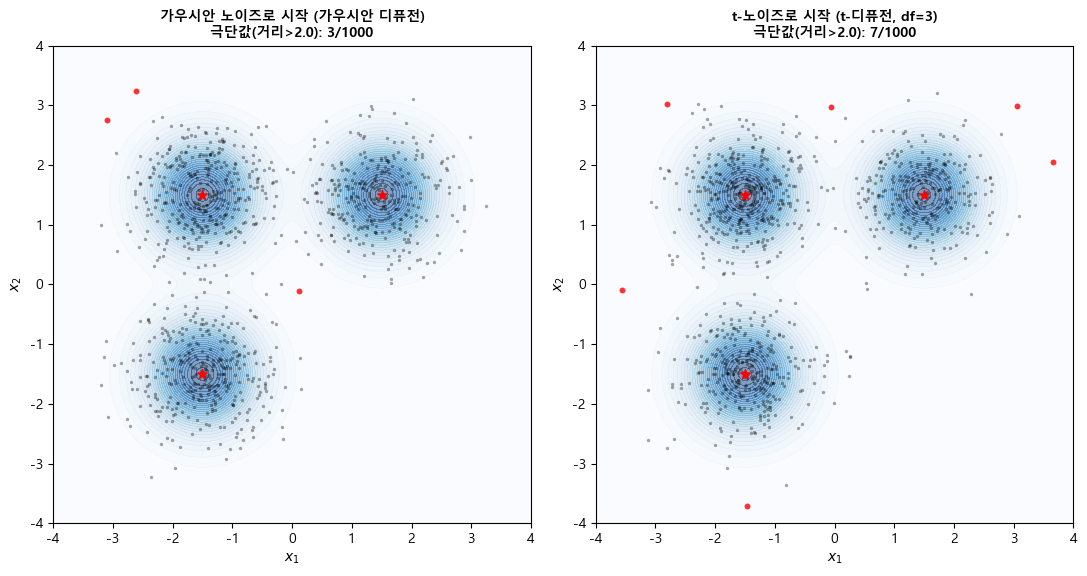

In [149]:
n_particles_diff_final = 1000
n_steps_diff_final = 150
df_diff_final = 3
extreme_threshold_diff = 2.0

fig8, axes8 = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, noise_mode, title in [
    (axes8[0], "gaussian", "가우시안 노이즈로 시작 (가우시안 디퓨전)"),
    (axes8[1], "t", f"t-노이즈로 시작 (t-디퓨전, df={df_diff_final})"),
]:
    rng_x = np.random.default_rng(7)
    _, traj_x = run_prior_langevin(noise_mode, n_particles_diff_final, df_diff_final, step_size, n_steps_diff_final, rng_x)
    end_x = traj_x[-1]
    dist_x = np.min(np.linalg.norm(end_x[:, None, :] - means[None, :, :], axis=2), axis=1)
    is_extreme_x = dist_x > extreme_threshold_diff

    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    ax.scatter(end_x[~is_extreme_x, 0], end_x[~is_extreme_x, 1], s=6, c="black", alpha=0.35, linewidths=0)
    ax.scatter(end_x[is_extreme_x, 0], end_x[is_extreme_x, 1], s=18, c="red", alpha=0.8, linewidths=0)
    ax.scatter(means[:, 0], means[:, 1], c="red", s=50, marker="*", zorder=5)
    ax.set_title(f"{title}\n극단값(거리>{extreme_threshold_diff}): {int(is_extreme_x.sum())}/{n_particles_diff_final}", fontweight="bold", fontsize=10)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### 6-3. 노이즈 분포에서 시작했을 때도 paired t-test로 확인하기

In [150]:
n_trials_diff = 20
n_particles_diff_stat = 1000
n_steps_diff_stat = 150
df_diff_stat = 3
extreme_threshold_diff_stat = 2.0

frac_gauss_diff = np.zeros(n_trials_diff)
frac_t_diff = np.zeros(n_trials_diff)

for trial in range(n_trials_diff):
    seed = 2000 + trial

    rng_g = np.random.default_rng(seed)
    _, traj_g = run_prior_langevin("gaussian", n_particles_diff_stat, df_diff_stat, step_size, n_steps_diff_stat, rng_g)
    end_g = traj_g[-1]

    rng_t = np.random.default_rng(seed)  # 같은 시드로 t prior에서도 뽑아서 공정하게 비교
    _, traj_t = run_prior_langevin("t", n_particles_diff_stat, df_diff_stat, step_size, n_steps_diff_stat, rng_t)
    end_t = traj_t[-1]

    dist_g = np.min(np.linalg.norm(end_g[:, None, :] - means[None, :, :], axis=2), axis=1)
    dist_t = np.min(np.linalg.norm(end_t[:, None, :] - means[None, :, :], axis=2), axis=1)
    frac_gauss_diff[trial] = np.mean(dist_g > extreme_threshold_diff_stat)
    frac_t_diff[trial] = np.mean(dist_t > extreme_threshold_diff_stat)

diff_diff = frac_t_diff - frac_gauss_diff
n_t_wins_diff = int(np.sum(frac_t_diff > frac_gauss_diff))
n_g_wins_diff = int(np.sum(frac_gauss_diff > frac_t_diff))

print(f"시드 {n_trials_diff}개, 시드당 입자 {n_particles_diff_stat}개, threshold={extreme_threshold_diff_stat} (시작점: 노이즈 prior)")
print()
print(f"가우시안 디퓨전: 극단값 비율 평균={frac_gauss_diff.mean():.4f}  표준편차={frac_gauss_diff.std():.4f}")
print(f"t-디퓨전       : 극단값 비율 평균={frac_t_diff.mean():.4f}  표준편차={frac_t_diff.std():.4f}")
print(f"시드별 비교: t가 더 큼={n_t_wins_diff}/{n_trials_diff}  가우시안이 더 큼={n_g_wins_diff}/{n_trials_diff}")

시드 20개, 시드당 입자 1000개, threshold=2.0 (시작점: 노이즈 prior)

가우시안 디퓨전: 극단값 비율 평균=0.0034  표준편차=0.0018
t-디퓨전       : 극단값 비율 평균=0.0095  표준편차=0.0031
시드별 비교: t가 더 큼=20/20  가우시안이 더 큼=0/20


In [151]:
from scipy import stats

ttest_diff = stats.ttest_rel(frac_t_diff, frac_gauss_diff)
ci_diff = ttest_diff.confidence_interval(confidence_level=0.95)

print("paired t-test: t-디퓨전 vs 가우시안 디퓨전 (극단값 비율, 노이즈 prior 시작, 시드 40개)")
print(f"  평균 차이 (t - 가우시안) = {diff_diff.mean():.4f}")
print(f"  t-통계량 = {ttest_diff.statistic:.3f}")
print(f"  p-value  = {ttest_diff.pvalue:.16f}")
print(f"  95% 신뢰구간 = [{ci_diff.low:.4f}, {ci_diff.high:.4f}]")
print()
if ttest_diff.pvalue < 0.05:
    print("-> p < 0.05: 유의수준 5%에서 통계적으로 유의미한 차이")
else:
    print("-> p >= 0.05: 유의수준 5%에서 통계적으로 유의미하다고 보기 어려움 (신뢰구간이 0을 포함)")

paired t-test: t-디퓨전 vs 가우시안 디퓨전 (극단값 비율, 노이즈 prior 시작, 시드 40개)
  평균 차이 (t - 가우시안) = 0.0061
  t-통계량 = 9.781
  p-value  = 0.0000000075094244
  95% 신뢰구간 = [0.0048, 0.0074]

-> p < 0.05: 유의수준 5%에서 통계적으로 유의미한 차이
